<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Feature Detection em Reconstrucao 3D

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

## Introducao

Antes de qualquer reconstrucao 3D, o algoritmo precisa encontrar **pontos distintivos** em cada imagem que possam ser reconhecidos em multiplas vistas. Isso e o **feature detection**.

Neste notebook, vamos implementar o algoritmo **SIFT** (Scale-Invariant Feature Transform) do zero, passo a passo, usando apenas NumPy e SciPy. Ao final, comparamos com a implementacao otimizada do OpenCV.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
import urllib.request
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
})

## Carregar imagem de amostra

Vamos usar uma foto do dataset **South Building** (UNC Chapel Hill), o mesmo dataset usado pelo COLMAP como benchmark. A imagem mostra um predio com muita textura arquitetonica, ideal para detectar features.

Resolucao: 1536 x 1152


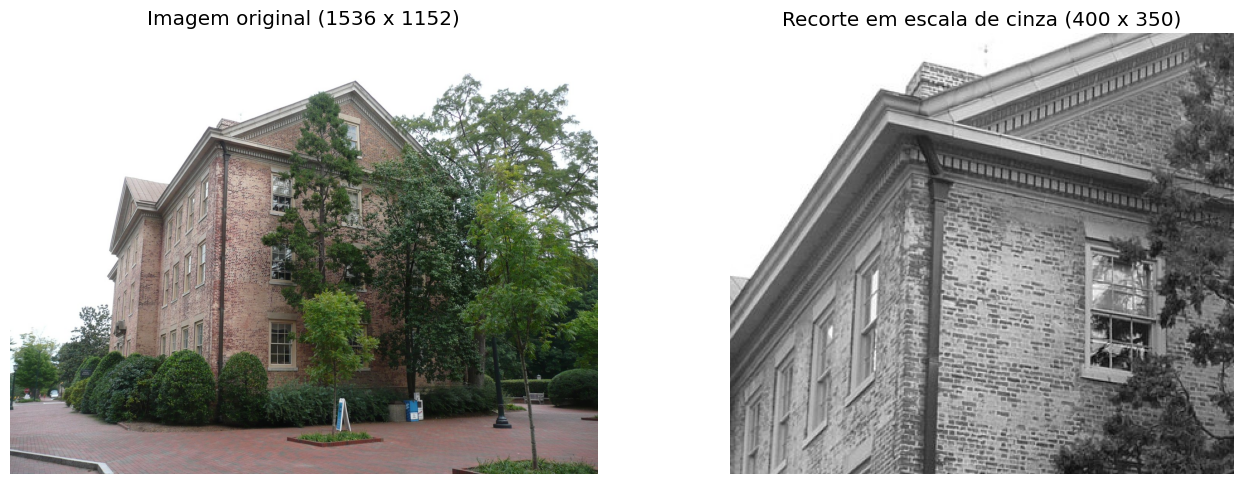

In [2]:
# Baixar imagem de amostra do repositorio
IMG_URL = "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/feature-detection-reconstrucao-3d/south_building_sample.jpg"
IMG_PATH = Path("south_building_sample.jpg")

if not IMG_PATH.exists():
    print("Baixando imagem de amostra...")
    urllib.request.urlretrieve(IMG_URL, IMG_PATH)

img_full = Image.open(IMG_PATH)
print(f"Resolucao: {img_full.size[0]} x {img_full.size[1]}")

# Recorte para acelerar o processamento em Python puro
img_crop = img_full.crop((400, 200, 800, 550))
img_gray = np.array(img_crop.convert('L')).astype(np.float64) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_full)
axes[0].set_title(f'Imagem original ({img_full.size[0]} x {img_full.size[1]})')
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title(f'Recorte em escala de cinza ({img_gray.shape[1]} x {img_gray.shape[0]})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Passo 1 — Espaco de Escalas (Piramide Gaussiana)

O insight central do SIFT e que features existem em diferentes **escalas**. Um canto de janela e visivel de perto, mas de longe se mistura com a parede.

Para detectar features em todas as escalas, construimos um **espaco de escalas** convoluindo a imagem com filtros gaussianos de largura crescente:

$$L(x, y, \sigma) = G(x, y, \sigma) * I(x, y)$$

Organizamos isso em **oitavas**. Em cada oitava, o blur aumenta por um fator constante $k = 2^{1/s}$. Entre oitavas, reduzimos a resolucao pela metade.

In [3]:
def construir_espaco_escalas(imagem, n_oitavas=4, n_escalas_por_oitava=5, sigma_base=1.6):
    """
    Constroi o espaco de escalas como uma lista de oitavas.
    Cada oitava contem imagens gaussianas com sigma crescente.
    """
    s = n_escalas_por_oitava - 3
    k = 2 ** (1.0 / s)

    oitavas = []
    atual = imagem.copy()

    for o in range(n_oitavas):
        sigmas = [sigma_base * (k ** i) for i in range(n_escalas_por_oitava)]
        imgs_oitava = [gaussian_filter(atual, sigma=sig) for sig in sigmas]
        oitavas.append((imgs_oitava, sigmas, atual.shape))

        # Reduzir resolucao para a proxima oitava
        atual = imgs_oitava[-3][::2, ::2]

    return oitavas

In [4]:
oitavas = construir_espaco_escalas(img_gray, n_oitavas=4, n_escalas_por_oitava=5)

for i, (imgs, sigmas, shape) in enumerate(oitavas):
    print(f'Oitava {i}: {shape}, {len(imgs)} escalas, sigma = [{sigmas[0]:.2f} ... {sigmas[-1]:.2f}]')

Oitava 0: (350, 400), 5 escalas, sigma = [1.60 ... 6.40]
Oitava 1: (175, 200), 5 escalas, sigma = [1.60 ... 6.40]
Oitava 2: (88, 100), 5 escalas, sigma = [1.60 ... 6.40]
Oitava 3: (44, 50), 5 escalas, sigma = [1.60 ... 6.40]


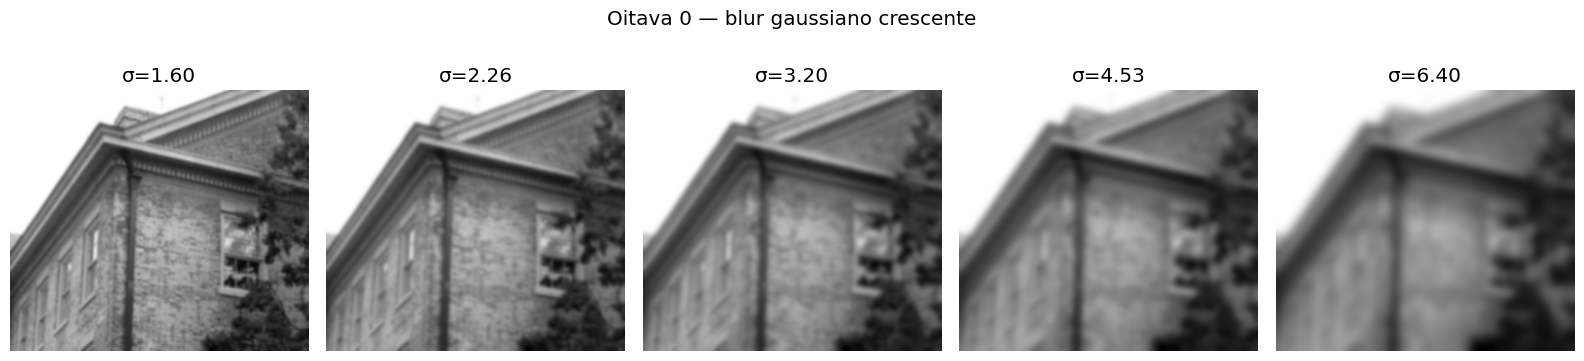

In [5]:
# Visualizar a primeira oitava
imgs, sigmas, _ = oitavas[0]

fig, axes = plt.subplots(1, len(imgs), figsize=(16, 4))
for ax, im, sig in zip(axes, imgs, sigmas):
    ax.imshow(im, cmap='gray')
    ax.set_title(f'\u03c3={sig:.2f}')
    ax.axis('off')
plt.suptitle('Oitava 0 — blur gaussiano crescente')
plt.tight_layout()
plt.show()

Conforme o sigma aumenta, detalhes finos desaparecem. Bordas pequenas e texturas sao suavizadas, restando apenas estruturas grosseiras. Features detectadas com sigma grande sao features "grandes"; com sigma pequeno, sao detalhes finos.

## Passo 2 — Diferenca de Gaussianas (DoG)

Para encontrar keypoints, precisamos detectar pontos que se "destacam" numa escala particular. O operador ideal seria o **Laplaciano da Gaussiana** (LoG), mas ele e caro de calcular.

O insight de Lowe: a **Diferenca de Gaussianas** e uma boa aproximacao:

$$D(x, y, \sigma) = L(x, y, k\sigma) - L(x, y, \sigma) \approx (k - 1) \cdot \sigma^2 \nabla^2 L$$

Como ja temos $L$ em multiplas escalas, calcular DoG e so uma subtracao.

In [6]:
def calcular_dog(oitavas):
    """Calcula a Diferenca de Gaussianas para cada oitava."""
    dog_oitavas = []
    for imgs, sigmas, shape in oitavas:
        dogs = [imgs[i+1] - imgs[i] for i in range(len(imgs) - 1)]
        dog_oitavas.append(dogs)
    return dog_oitavas

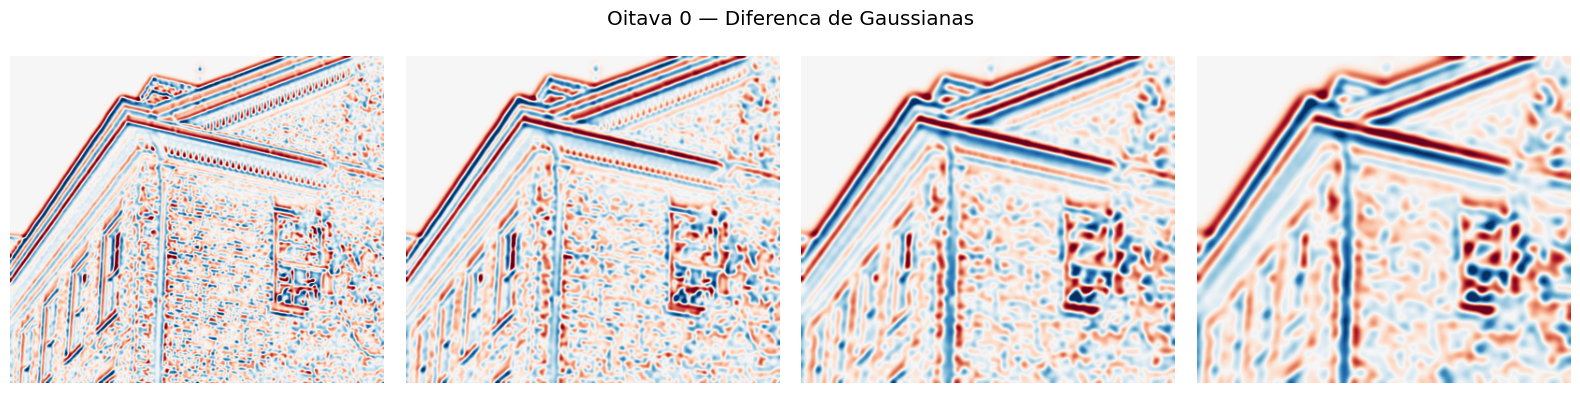

In [7]:
dog_oitavas = calcular_dog(oitavas)

# Visualizar DoG da primeira oitava
fig, axes = plt.subplots(1, len(dog_oitavas[0]), figsize=(16, 4))
for ax, dog in zip(axes, dog_oitavas[0]):
    ax.imshow(dog, cmap='RdBu', vmin=-0.05, vmax=0.05)
    ax.axis('off')
plt.suptitle('Oitava 0 — Diferenca de Gaussianas')
plt.tight_layout()
plt.show()

As regioes vermelhas/azuis no DoG sao pontos com forte contraste local. Areas uniformes (ceu, parede lisa) ficam perto de zero.

## Passo 3 — Deteccao de Keypoints (Extremos no DoG)

Um keypoint e um ponto que e **extremo local** (maximo ou minimo) no DoG, comparado com seus 26 vizinhos: 8 vizinhos espaciais na mesma escala, mais 9 na escala acima e 9 na escala abaixo.

In [8]:
def detectar_extremos(dog_oitavas, limiar_contraste=0.04):
    """
    Encontra extremos locais na piramide DoG.
    Um ponto e extremo se for maior (ou menor) que todos os 26 vizinhos.
    """
    keypoints = []  # (oitava, escala, y, x, resposta)

    for o, dogs in enumerate(dog_oitavas):
        for s in range(1, len(dogs) - 1):
            anterior, atual, proximo = dogs[s-1], dogs[s], dogs[s+1]
            h, w = atual.shape

            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    val = atual[y, x]

                    # Verificacao rapida de contraste
                    if abs(val) < limiar_contraste:
                        continue

                    # Extrair patches 3x3 das tres escalas
                    cubo = np.array([
                        anterior[y-1:y+2, x-1:x+2],
                        atual[y-1:y+2, x-1:x+2],
                        proximo[y-1:y+2, x-1:x+2],
                    ])

                    if val == cubo.max() or val == cubo.min():
                        keypoints.append((o, s, y, x, val))

    return keypoints

Encontrados 321 keypoints brutos (antes da filtragem)


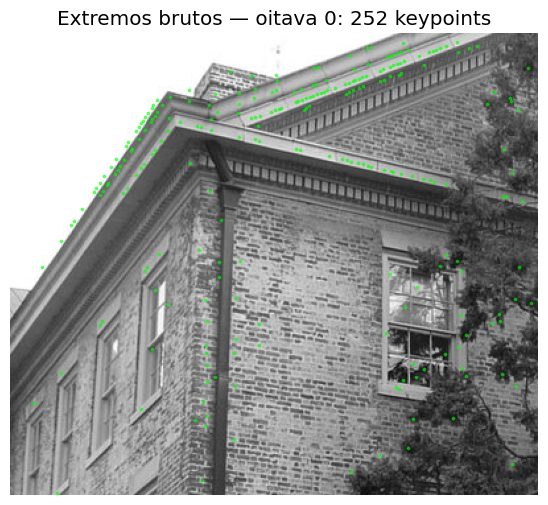

In [9]:
keypoints_brutos = detectar_extremos(dog_oitavas, limiar_contraste=0.03)
print(f'Encontrados {len(keypoints_brutos)} keypoints brutos (antes da filtragem)')

# Visualizar keypoints brutos (apenas oitava 0)
oct0_kps = [(y, x) for o, s, y, x, v in keypoints_brutos if o == 0]

plt.imshow(img_gray, cmap='gray')
if oct0_kps:
    ys, xs = zip(*oct0_kps)
    plt.scatter(xs, ys, s=3, c='lime', alpha=0.5)
plt.title(f'Extremos brutos — oitava 0: {len(oct0_kps)} keypoints')
plt.axis('off')
plt.show()

## Passo 4 — Rejeicao de Bordas (Filtro tipo Harris)

Pontos em bordas sao mal localizados. Para detecta-los, usamos a **matriz Hessiana** do DoG:

$$\mathbf{H} = \begin{bmatrix} D_{xx} & D_{xy} \\ D_{xy} & D_{yy} \end{bmatrix}$$

Rejeitamos o ponto se a razao entre os autovalores for muito alta (borda), usando o teste eficiente de Lowe:

$$\frac{\text{Tr}(\mathbf{H})^2}{\text{Det}(\mathbf{H})} > \frac{(r + 1)^2}{r}$$

onde $r = 10$ e o limiar.

In [10]:
def filtrar_bordas(dog_oitavas, keypoints, r_limiar=10):
    """Remove keypoints em bordas usando a razao de autovalores da Hessiana."""
    filtrados = []
    r_teste = (r_limiar + 1) ** 2 / r_limiar

    for o, s, y, x, val in keypoints:
        dog = dog_oitavas[o][s]

        # Hessiana 2x2 por diferencas finitas
        dxx = dog[y, x+1] + dog[y, x-1] - 2 * dog[y, x]
        dyy = dog[y+1, x] + dog[y-1, x] - 2 * dog[y, x]
        dxy = (dog[y+1, x+1] - dog[y+1, x-1] - dog[y-1, x+1] + dog[y-1, x-1]) / 4.0

        traco = dxx + dyy
        det = dxx * dyy - dxy * dxy

        if det <= 0:
            continue

        if traco ** 2 / det < r_teste:
            filtrados.append((o, s, y, x, val))

    return filtrados

Apos rejeicao de bordas: 120 keypoints (removidos 201)


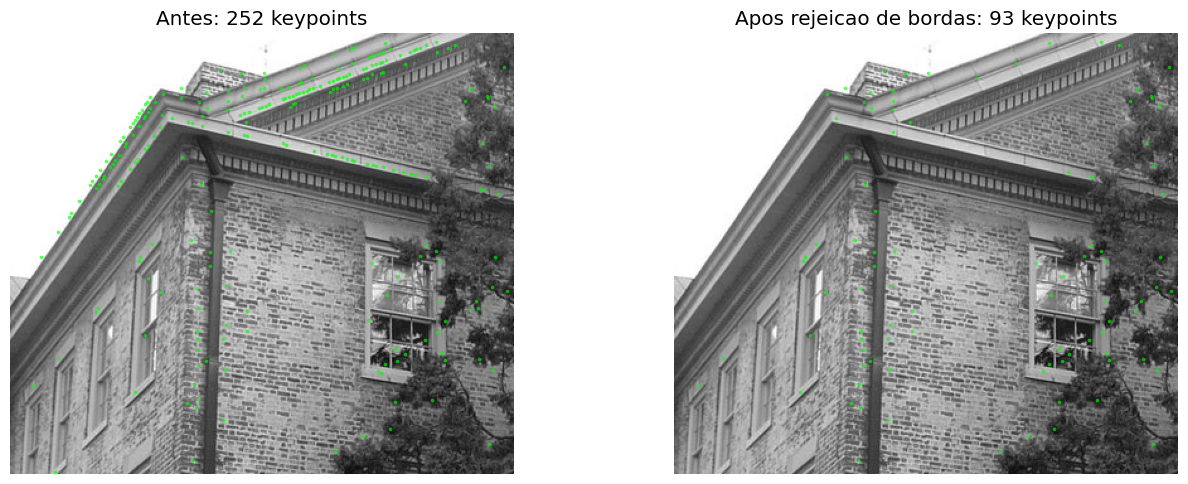

In [11]:
keypoints_filtrados = filtrar_bordas(dog_oitavas, keypoints_brutos)
print(f'Apos rejeicao de bordas: {len(keypoints_filtrados)} keypoints (removidos {len(keypoints_brutos) - len(keypoints_filtrados)})')

# Comparar antes e depois
oct0_brutos = [(y, x) for o, s, y, x, v in keypoints_brutos if o == 0]
oct0_filtrados = [(y, x) for o, s, y, x, v in keypoints_filtrados if o == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray, cmap='gray')
if oct0_brutos:
    ys, xs = zip(*oct0_brutos)
    axes[0].scatter(xs, ys, s=3, c='lime', alpha=0.5)
axes[0].set_title(f'Antes: {len(oct0_brutos)} keypoints')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
if oct0_filtrados:
    ys, xs = zip(*oct0_filtrados)
    axes[1].scatter(xs, ys, s=3, c='lime', alpha=0.5)
axes[1].set_title(f'Apos rejeicao de bordas: {len(oct0_filtrados)} keypoints')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Passo 5 — Atribuicao de Orientacao

Para tornar o descritor invariante a rotacao, atribuimos uma **orientacao dominante** a cada keypoint.

Calculamos o gradiente (magnitude e direcao) em cada pixel e construimos um **histograma de 36 bins** na vizinhanca do keypoint. O pico do histograma e a orientacao dominante.

In [12]:
def calcular_gradientes(imagem):
    """Calcula magnitude e orientacao do gradiente para cada pixel."""
    dy = np.zeros_like(imagem)
    dx = np.zeros_like(imagem)
    dy[1:-1, :] = imagem[2:, :] - imagem[:-2, :]
    dx[:, 1:-1] = imagem[:, 2:] - imagem[:, :-2]

    magnitude = np.sqrt(dx**2 + dy**2)
    orientacao = np.arctan2(dy, dx)
    return magnitude, orientacao


def atribuir_orientacoes(oitavas, keypoints, n_bins=36):
    """
    Atribui orientacao dominante a cada keypoint.
    Retorna keypoints com orientacao: (oitava, escala, y, x, resposta, angulo).
    """
    orientados = []
    raio = 8

    for o, s, y, x, val in keypoints:
        img = oitavas[o][0][s]
        h, w = img.shape

        if y - raio < 0 or y + raio >= h or x - raio < 0 or x + raio >= w:
            continue

        mag, ori = calcular_gradientes(img)

        patch_mag = mag[y-raio:y+raio+1, x-raio:x+raio+1]
        patch_ori = ori[y-raio:y+raio+1, x-raio:x+raio+1]

        # Peso gaussiano centrado no keypoint
        gauss_peso = gaussian_filter(np.ones_like(patch_mag), sigma=1.5 * raio / 2)
        mag_ponderada = patch_mag * gauss_peso

        # Histograma de orientacoes
        hist = np.zeros(n_bins)
        largura_bin = 2 * np.pi / n_bins
        for dy in range(patch_mag.shape[0]):
            for dx in range(patch_mag.shape[1]):
                angulo = patch_ori[dy, dx] % (2 * np.pi)
                b = int(angulo / largura_bin) % n_bins
                hist[b] += mag_ponderada[dy, dx]

        bin_dominante = np.argmax(hist)
        angulo_dominante = bin_dominante * largura_bin

        orientados.append((o, s, y, x, val, angulo_dominante))

    return orientados

116 keypoints com orientacao atribuida


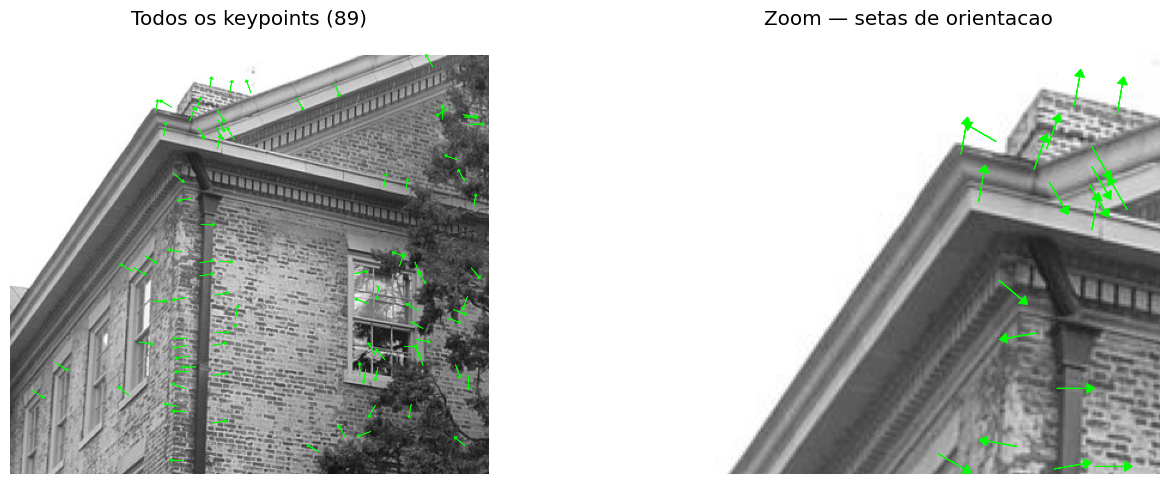

In [13]:
keypoints_orientados = atribuir_orientacoes(oitavas, keypoints_filtrados)
print(f'{len(keypoints_orientados)} keypoints com orientacao atribuida')

# Visualizar keypoints com setas de orientacao
oct0 = [(y, x, angulo) for o, s, y, x, v, angulo in keypoints_orientados if o == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray, cmap='gray')
for y, x, angulo in oct0:
    dx = np.cos(angulo) * 10
    dy = np.sin(angulo) * 10
    axes[0].arrow(x, y, dx, dy, head_width=3, head_length=2, fc='lime', ec='lime', linewidth=0.5)
axes[0].set_title(f'Todos os keypoints ({len(oct0)})')
axes[0].axis('off')

# Zoom numa regiao
axes[1].imshow(img_gray, cmap='gray')
h_img, w_img = img_gray.shape
for y, x, angulo in oct0:
    if x < w_img // 2 and y < h_img // 2:
        dx = np.cos(angulo) * 12
        dy = np.sin(angulo) * 12
        axes[1].arrow(x, y, dx, dy, head_width=4, head_length=3, fc='lime', ec='lime', linewidth=0.8)
axes[1].set_xlim(0, w_img // 2)
axes[1].set_ylim(h_img // 2, 0)
axes[1].set_title('Zoom — setas de orientacao')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Cada seta mostra a direcao dominante do gradiente naquele keypoint. Essa orientacao sera usada para rotacionar o patch do descritor, tornando-o invariante a rotacao da camera.

## Passo 6 — O Descritor (128 dimensoes)

Para cada keypoint na posicao $(x, y)$ com orientacao $\theta$:

1. Pegamos um patch $16 \times 16$ ao redor do keypoint, **rotacionado** para alinhar com $\theta$
2. Dividimos em uma grade $4 \times 4$ de celulas (cada celula tem $4 \times 4$ pixels)
3. Em cada celula, calculamos um **histograma de 8 bins** de orientacoes do gradiente
4. Concatenamos: $4 \times 4 \times 8 = \mathbf{128}$ valores
5. Normalizamos, cortamos em 0.2 e renormalizamos

In [14]:
def calcular_descritor(imagem, y, x, angulo, tamanho_patch=16, n_celulas=4, n_bins=8):
    """
    Calcula um descritor SIFT para um unico keypoint.
    Retorna um vetor de 128 dimensoes.
    """
    h, w = imagem.shape
    metade = tamanho_patch // 2
    tamanho_celula = tamanho_patch // n_celulas

    margem = int(metade * 1.5)
    if y - margem < 0 or y + margem >= h or x - margem < 0 or x + margem >= w:
        return None

    mag, ori = calcular_gradientes(imagem)

    cos_a, sin_a = np.cos(-angulo), np.sin(-angulo)
    descritor = np.zeros((n_celulas, n_celulas, n_bins))

    for i in range(-metade, metade):
        for j in range(-metade, metade):
            # Rotacionar (i, j) pela orientacao do keypoint
            ri = int(round(cos_a * i - sin_a * j))
            rj = int(round(sin_a * i + cos_a * j))

            py, px = y + ri, x + rj
            if py < 0 or py >= h or px < 0 or px >= w:
                continue

            ci = (i + metade) // tamanho_celula
            cj = (j + metade) // tamanho_celula
            if ci >= n_celulas or cj >= n_celulas:
                continue

            # Orientacao relativa ao keypoint
            rel_ori = (ori[py, px] - angulo) % (2 * np.pi)
            idx_bin = int(rel_ori / (2 * np.pi / n_bins)) % n_bins

            # Peso gaussiano
            gauss_w = np.exp(-(i**2 + j**2) / (2 * (metade * 0.5)**2))
            descritor[ci, cj, idx_bin] += mag[py, px] * gauss_w

    # Achatar para vetor de 128 dimensoes
    desc = descritor.flatten()

    # Normalizar, cortar em 0.2, renormalizar
    norma = np.linalg.norm(desc)
    if norma > 0:
        desc = desc / norma
    desc = np.clip(desc, 0, 0.2)
    norma = np.linalg.norm(desc)
    if norma > 0:
        desc = desc / norma

    return desc

In [15]:
# Calcular descritores para todos os keypoints da oitava 0
descritores = []
keypoints_validos = []

for o, s, y, x, val, angulo in keypoints_orientados:
    if o != 0:
        continue
    img = oitavas[o][0][s]
    desc = calcular_descritor(img, y, x, angulo)
    if desc is not None:
        descritores.append(desc)
        keypoints_validos.append((y, x, angulo))

descritores = np.array(descritores)
print(f'{len(descritores)} descritores calculados, shape: {descritores.shape}')

87 descritores calculados, shape: (87, 128)


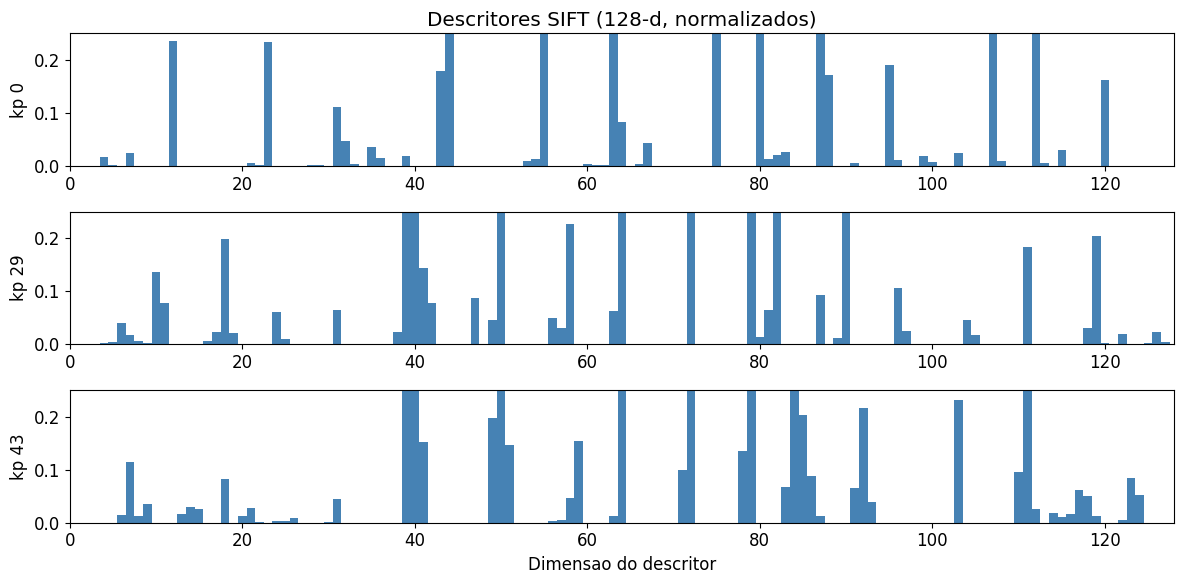

In [16]:
# Visualizar alguns descritores
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

for ax, i in zip(axes, [0, len(descritores)//3, len(descritores)//2]):
    ax.bar(range(128), descritores[i], width=1, color='steelblue')
    ax.set_ylabel(f'kp {i}')
    ax.set_xlim(0, 128)
    ax.set_ylim(0, 0.25)

axes[-1].set_xlabel('Dimensao do descritor')
axes[0].set_title('Descritores SIFT (128-d, normalizados)')
plt.tight_layout()
plt.show()

## Comparacao com o SIFT do OpenCV

Vamos verificar nossa implementacao contra o SIFT otimizado do OpenCV. Os resultados nao serao identicos (pulamos refinamento sub-pixel e outras otimizacoes), mas as localizacoes devem ser similares.

In [17]:
import cv2

img_uint8 = (img_gray * 255).astype(np.uint8)
sift = cv2.SIFT_create()
cv_kps, cv_descs = sift.detectAndCompute(img_uint8, None)

print(f'OpenCV SIFT: {len(cv_kps)} keypoints')
print(f'Nosso SIFT:  {len(keypoints_validos)} keypoints (apenas oitava 0)')

OpenCV SIFT: 1465 keypoints
Nosso SIFT:  87 keypoints (apenas oitava 0)


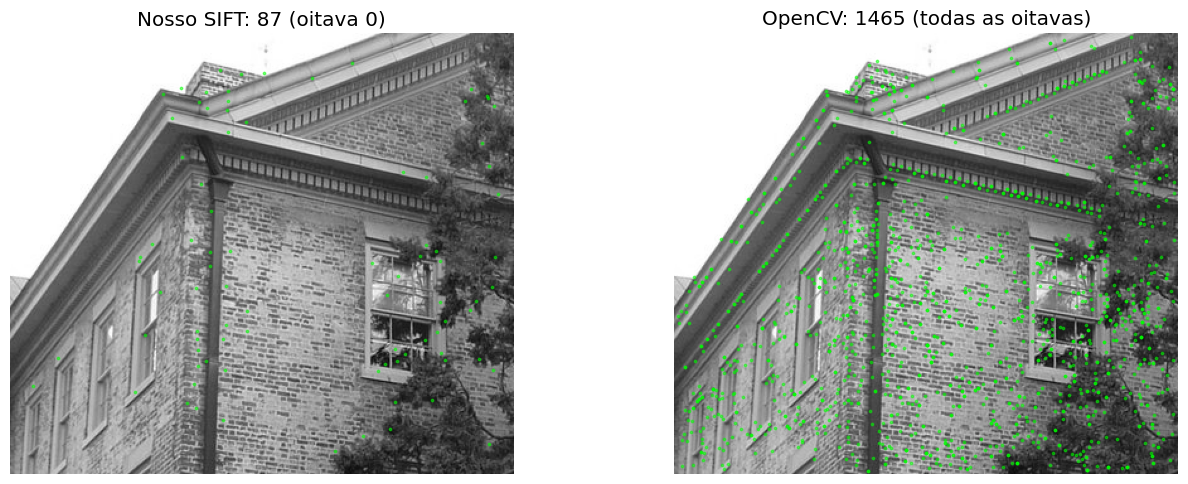

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nossos keypoints
axes[0].imshow(img_gray, cmap='gray')
if keypoints_validos:
    ys, xs, _ = zip(*keypoints_validos)
    axes[0].scatter(xs, ys, s=3, c='lime', alpha=0.5)
axes[0].set_title(f'Nosso SIFT: {len(keypoints_validos)} (oitava 0)')
axes[0].axis('off')

# OpenCV
axes[1].imshow(img_gray, cmap='gray')
cv_xs = [kp.pt[0] for kp in cv_kps]
cv_ys = [kp.pt[1] for kp in cv_kps]
axes[1].scatter(cv_xs, cv_ys, s=3, c='lime', alpha=0.5)
axes[1].set_title(f'OpenCV: {len(cv_kps)} (todas as oitavas)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Nossa implementacao detecta keypoints em locais similares ao OpenCV. A contagem e diferente porque so calculamos a oitava 0, e pulamos o refinamento sub-pixel.

O ponto deste exercicio nao e igualar a performance do OpenCV. E entender que o SIFT nao e magica: sao blurs gaussianos, subtracoes, histogramas de gradiente e limiares bem pensados.

## Resumo

Implementamos o pipeline SIFT do zero:

1. **Espaco de escalas** — blur gaussiano com sigma crescente, organizado em oitavas
2. **DoG** — subtracao entre niveis consecutivos de blur (detector de blobs)
3. **Deteccao de extremos** — encontrar pontos que sao max/min locais no espaco e na escala (26 vizinhos)
4. **Rejeicao de bordas** — descartar pontos em bordas usando a razao de autovalores da Hessiana
5. **Orientacao** — atribuir direcao dominante do gradiente para invariancia a rotacao
6. **Descritor** — grade 4x4 de histogramas de 8 bins = 128 dimensoes

Isso e exatamente o que o `feature_extractor` do COLMAP faz internamente (com aceleracao GPU e varias otimizacoes que pulamos). Mas a matematica e a mesma.